In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

In [3]:
# Import modules
import sys
import os

# Add parent directory to path for imports
# This ensures util.utils can be found when imported from alpha_model modules
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# Change working directory to parent so relative paths work
os.chdir(parent_dir)

# Momentum strategies
from alpha_model.momentum_strategies import (
    load_historical_data, load_all_symbols,
    PriceMomentum, RSIMomentum, MACDMomentum,
    VolumeWeightedMomentum, OBVMomentum, MFIMomentum,
    TripleMomentum, AcceleratingMomentum, ROCMomentum, VPTMomentum,
    MomentumPortfolio, backtest_strategy, compare_strategies,
    calculate_rsi, calculate_macd, calculate_obv, calculate_mfi
)

# Fundamental strategies
from alpha_model.fundamental_strategies import (
    load_fundamental_data, load_all_fundamentals, merge_fundamental_data,
    ValueStrategy, QualityStrategy, GrowthStrategy, GARPStrategy,
    PiotroskiStrategy, DividendStrategy, FCFStrategy, CompositeStrategy,
    BalanceSheetStrength, FundamentalPortfolio,
    calculate_piotroski_score, generate_stock_report, compare_strategies as compare_fund_strategies
)

print("All modules imported successfully!")

All modules imported successfully!


In [4]:
# ========== COMMON VISUALIZATION FUNCTIONS ==========

def plot_strategy_analysis(df, result_df, backtest_result, strategy_name, indicator_col=None, indicator_name=None):
    """
    Common function to visualize strategy analysis.
    
    Args:
        df: Original dataframe with price data
        result_df: Dataframe with strategy signals
        backtest_result: Backtest result dictionary
        strategy_name: Name of the strategy
        indicator_col: Column name for indicator to plot (optional)
        indicator_name: Display name for indicator (optional)
    """
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    # Plot 1: Price with Buy/Sell signals
    axes[0].plot(result_df['date'], result_df['adj_close'], label='Price', alpha=0.7, linewidth=1)
    
    # Mark buy/sell signals
    if 'signal' in result_df.columns:
        buy_signals = result_df[result_df['signal'].diff() == 1]
        sell_signals = result_df[result_df['signal'].diff() == -1]
        axes[0].scatter(buy_signals['date'], buy_signals['adj_close'], 
                       marker='^', color='green', s=100, label='Buy Signal', zorder=5)
        axes[0].scatter(sell_signals['date'], sell_signals['adj_close'], 
                       marker='v', color='red', s=100, label='Sell Signal', zorder=5)
    
    axes[0].set_title(f'{strategy_name} - Price & Signals', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Price')
    axes[0].legend(loc='upper left')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Indicator (if provided)
    if indicator_col and indicator_col in result_df.columns:
        axes[1].plot(result_df['date'], result_df[indicator_col], linewidth=1.2, color='purple')
        axes[1].set_title(indicator_name or indicator_col, fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Value')
        axes[1].grid(True, alpha=0.3)
    else:
        # Show position over time
        data = backtest_result['data']
        axes[1].fill_between(data['date'], data['position'], 0, alpha=0.5, step='pre', color='blue')
        axes[1].set_title('Position (1=Long, 0=Out)', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Position')
        axes[1].set_ylim(-0.1, 1.1)
        axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Cumulative Returns
    data = backtest_result['data']
    axes[2].plot(data['date'], data['cumulative_market'], label='Buy & Hold', linewidth=1.5)
    axes[2].plot(data['date'], data['cumulative_strategy_net'], label=strategy_name, linewidth=1.5)
    axes[2].set_title('Cumulative Returns Comparison', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Cumulative Return')
    axes[2].set_xlabel('Date')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def print_backtest_results(backtest_result, strategy_name):
    """Print backtest results in a formatted way."""
    print(f"\n{strategy_name}")
    print("="*50)
    print(f"Total Return:   {backtest_result['total_return']:.2%}")
    print(f"Annual Return:  {backtest_result['annual_return']:.2%}")
    print(f"Sharpe Ratio:   {backtest_result['sharpe_ratio']:.2f}")
    print(f"Max Drawdown:   {backtest_result['max_drawdown']:.2%}")
    print(f"Win Rate:       {backtest_result['win_rate']:.2%}")
    print(f"Num Trades:     {int(backtest_result['num_trades'])}")


def plot_comparison_charts(comparison_df):
    """Plot comparison charts for strategies."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Helper function
    def pct_to_float(pct_str):
        if isinstance(pct_str, str):
            return float(pct_str.strip('%')) / 100
        return pct_str
    
    strategies_names = comparison_df['Strategy'].tolist()
    sharpe_ratios = [float(x) for x in comparison_df['Sharpe Ratio'].tolist()]
    total_returns = [pct_to_float(x) for x in comparison_df['Total Return'].tolist()]
    max_drawdowns = [pct_to_float(x) for x in comparison_df['Max Drawdown'].tolist()]
    win_rates = [pct_to_float(x) for x in comparison_df['Win Rate'].tolist()]
    
    # Sharpe Ratio
    colors = ['green' if x > 0 else 'red' for x in sharpe_ratios]
    axes[0, 0].barh(strategies_names, sharpe_ratios, color=colors, alpha=0.7)
    axes[0, 0].set_title('Sharpe Ratio', fontsize=12, fontweight='bold')
    axes[0, 0].axvline(x=0, color='black', linewidth=0.5)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Total Return
    colors = ['green' if x > 0 else 'red' for x in total_returns]
    axes[0, 1].barh(strategies_names, total_returns, color=colors, alpha=0.7)
    axes[0, 1].set_title('Total Return', fontsize=12, fontweight='bold')
    axes[0, 1].axvline(x=0, color='black', linewidth=0.5)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Max Drawdown
    axes[1, 0].barh(strategies_names, max_drawdowns, color='red', alpha=0.7)
    axes[1, 0].set_title('Max Drawdown (lower is better)', fontsize=12, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Win Rate
    axes[1, 1].barh(strategies_names, win_rates, color='blue', alpha=0.7)
    axes[1, 1].set_title('Win Rate', fontsize=12, fontweight='bold')
    axes[1, 1].axvline(x=0.5, color='black', linewidth=0.5, linestyle='--')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_fundamental_comparison(fund_data, symbols, year, metrics_to_plot):
    """Plot fundamental metrics comparison across stocks."""
    n_metrics = len(metrics_to_plot)
    n_cols = min(3, n_metrics)
    n_rows = (n_metrics + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten() if n_metrics > 1 else [axes]
    
    # Collect data
    data_dict = {metric: [] for metric in metrics_to_plot}
    symbol_list = []
    
    for symbol in symbols:
        if symbol not in fund_data:
            continue
        merged = merge_fundamental_data(fund_data[symbol])
        year_data = merged[merged['year'] == year]
        if year_data.empty:
            continue
        
        row = year_data.iloc[-1]
        symbol_list.append(symbol)
        
        for metric, col_name in metrics_to_plot.items():
            data_dict[metric].append(row.get(col_name, np.nan))
    
    # Plot each metric
    for idx, (metric_name, values) in enumerate(data_dict.items()):
        ax = axes[idx]
        colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(symbol_list)))
        ax.barh(symbol_list, values, color=colors)
        ax.set_title(metric_name, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add median line
        valid_values = [v for v in values if not pd.isna(v)]
        if valid_values:
            ax.axvline(x=np.median(valid_values), color='red', linestyle='--', alpha=0.7, label='Median')
    
    # Hide unused axes
    for idx in range(len(metrics_to_plot), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f'Fundamental Metrics Comparison - {year}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [5]:
# ========== LOAD DATA ==========

# Import preprocessing utilities
from alpha_model.utils import (
    preprocess_historical_data, 
    check_data_quality, 
    print_data_quality_report,
    load_data_with_qlib
)

# Option 1: Load with Qlib (if available) - RECOMMENDED
# This will automatically use Qlib for data loading if available,
# otherwise fallback to CSV loading with preprocessing
USE_QLIB = False  # Set to True to use Qlib if installed

if USE_QLIB:
    symbols = ['VNM', 'VCB', 'VIC', 'VHM', 'HPG', 'MWG', 'VPB', 'MSN', 'ACB', 'BID']
    all_data = load_data_with_qlib(
        symbols=symbols,
        start_date='2020-01-01',
        end_date='2024-12-31',
        csv_dir='data/historical'
    )
else:
    # Option 2: Load from CSV and preprocess manually
    all_data_raw = load_all_symbols('data/historical')
    
    # Apply preprocessing to handle missing values and outliers
    all_data = {}
    for symbol, df in all_data_raw.items():
        all_data[symbol] = preprocess_historical_data(df)

print(f"Loaded historical data for {len(all_data)} symbols: {list(all_data.keys())}")

# Check data quality
print_data_quality_report(all_data)

# Load fundamental data for all symbols
fund_data = load_all_fundamentals('data/fundamental')
print(f"\nLoaded fundamental data for {len(fund_data)} symbols: {list(fund_data.keys())}")

# Select a sample symbol for demo
SYMBOL = 'VNM'
YEAR = 2024
df = all_data[SYMBOL].copy()
print(f"\nSample data for {SYMBOL}: {len(df)} rows, from {df['date'].min()} to {df['date'].max()}")

Loaded historical data for 10 symbols: ['ACB', 'BID', 'HPG', 'MSN', 'MWG', 'VCB', 'VHM', 'VIC', 'VNM', 'VPB']

DATA QUALITY REPORT

✓ ACB: 4737 rows, 2006-11-21 00:00:00 to 2025-12-03 00:00:00

✓ BID: 2956 rows, 2014-01-24 00:00:00 to 2025-12-03 00:00:00

✓ HPG: 4500 rows, 2007-11-15 00:00:00 to 2025-12-03 00:00:00

✓ MSN: 4011 rows, 2009-11-05 00:00:00 to 2025-12-03 00:00:00

✓ MWG: 2846 rows, 2014-07-14 00:00:00 to 2025-12-03 00:00:00

✓ VCB: 4101 rows, 2009-06-30 00:00:00 to 2025-12-03 00:00:00

✓ VHM: 1888 rows, 2018-05-17 00:00:00 to 2025-12-03 00:00:00

✓ VIC: 4541 rows, 2007-09-19 00:00:00 to 2025-12-03 00:00:00

✓ VNM: 4955 rows, 2006-01-19 00:00:00 to 2025-12-03 00:00:00

✓ VPB: 2071 rows, 2017-08-17 00:00:00 to 2025-12-03 00:00:00


Loaded fundamental data for 10 symbols: ['ACB', 'BID', 'HPG', 'MSN', 'MWG', 'VCB', 'VHM', 'VIC', 'VNM', 'VPB']

Sample data for VNM: 4955 rows, from 2006-01-19 00:00:00 to 2025-12-03 00:00:00


---
# Part I: Demo Strategies

## 1.1 Momentum Strategies Demo

Demo 3 momentum strategies:
1. **Price Momentum (MA Crossover)** - Trend following
2. **RSI Momentum** - Mean reversion with momentum
3. **MACD Momentum** - Momentum with confirmation


Price Momentum (SMA 20/50 Crossover)
Total Return:   1925.64%
Annual Return:  16.54%
Sharpe Ratio:   0.78
Max Drawdown:   -61.24%
Win Rate:       50.07%
Num Trades:     52


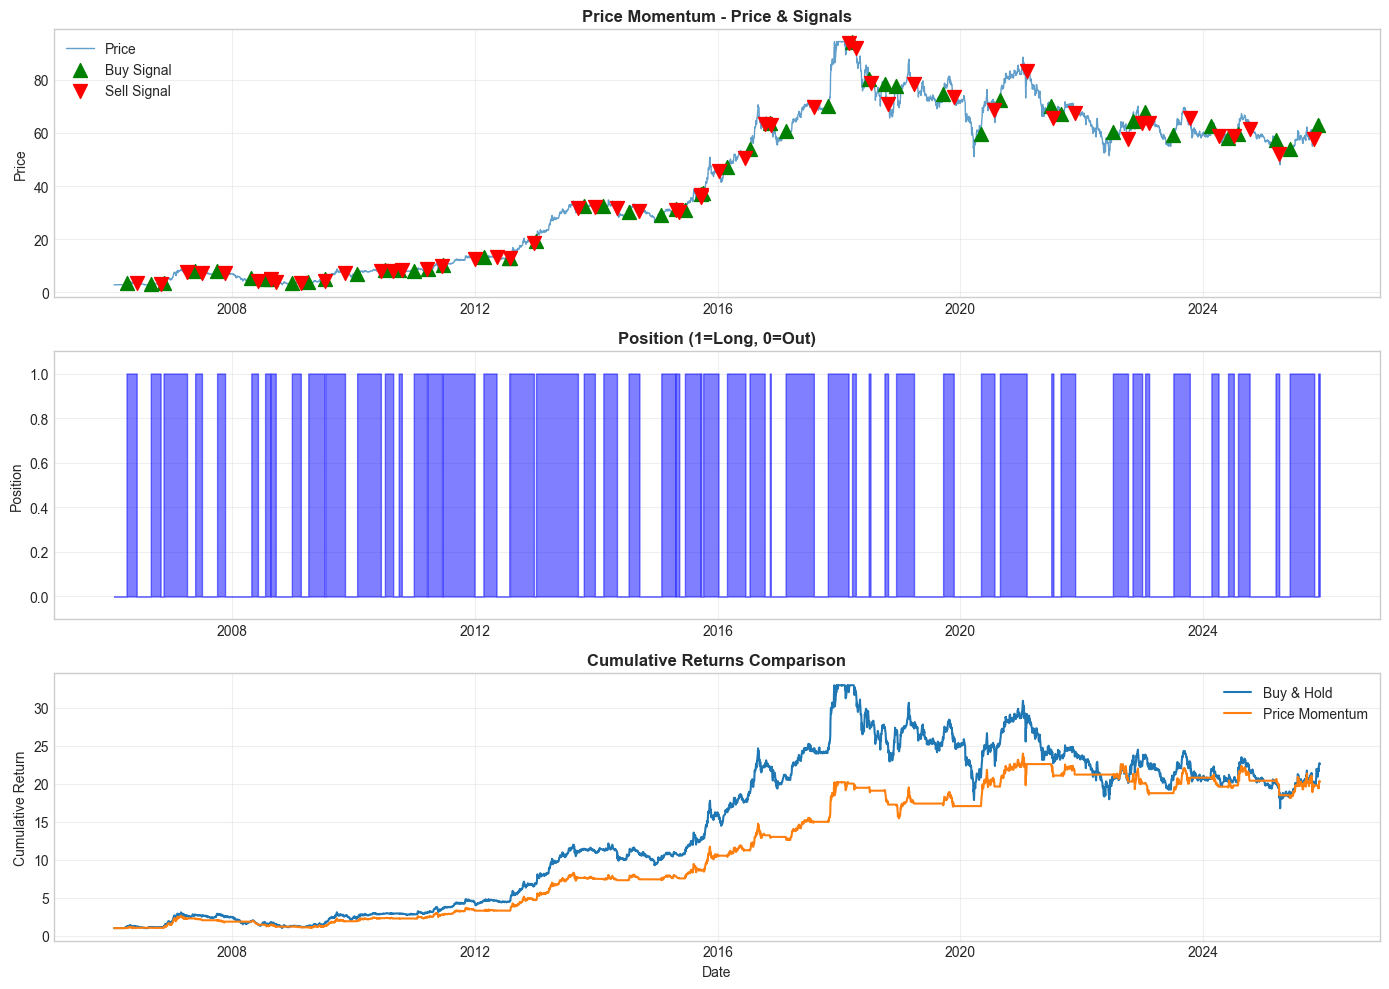

In [6]:
# ========== DEMO 1: PRICE MOMENTUM (MA CROSSOVER) ==========

strategy_1 = PriceMomentum(short_window=20, long_window=50)
result_1 = strategy_1.generate_signals(df)
backtest_1 = backtest_strategy(df, strategy_1)

# Print results
print_backtest_results(backtest_1, "Price Momentum (SMA 20/50 Crossover)")

# Visualize
plot_strategy_analysis(df, result_1, backtest_1, "Price Momentum")


RSI Momentum (14-period, 30/70)
Total Return:   4.06%
Annual Return:  0.20%
Sharpe Ratio:   0.01
Max Drawdown:   -52.71%
Win Rate:       46.15%
Num Trades:     55


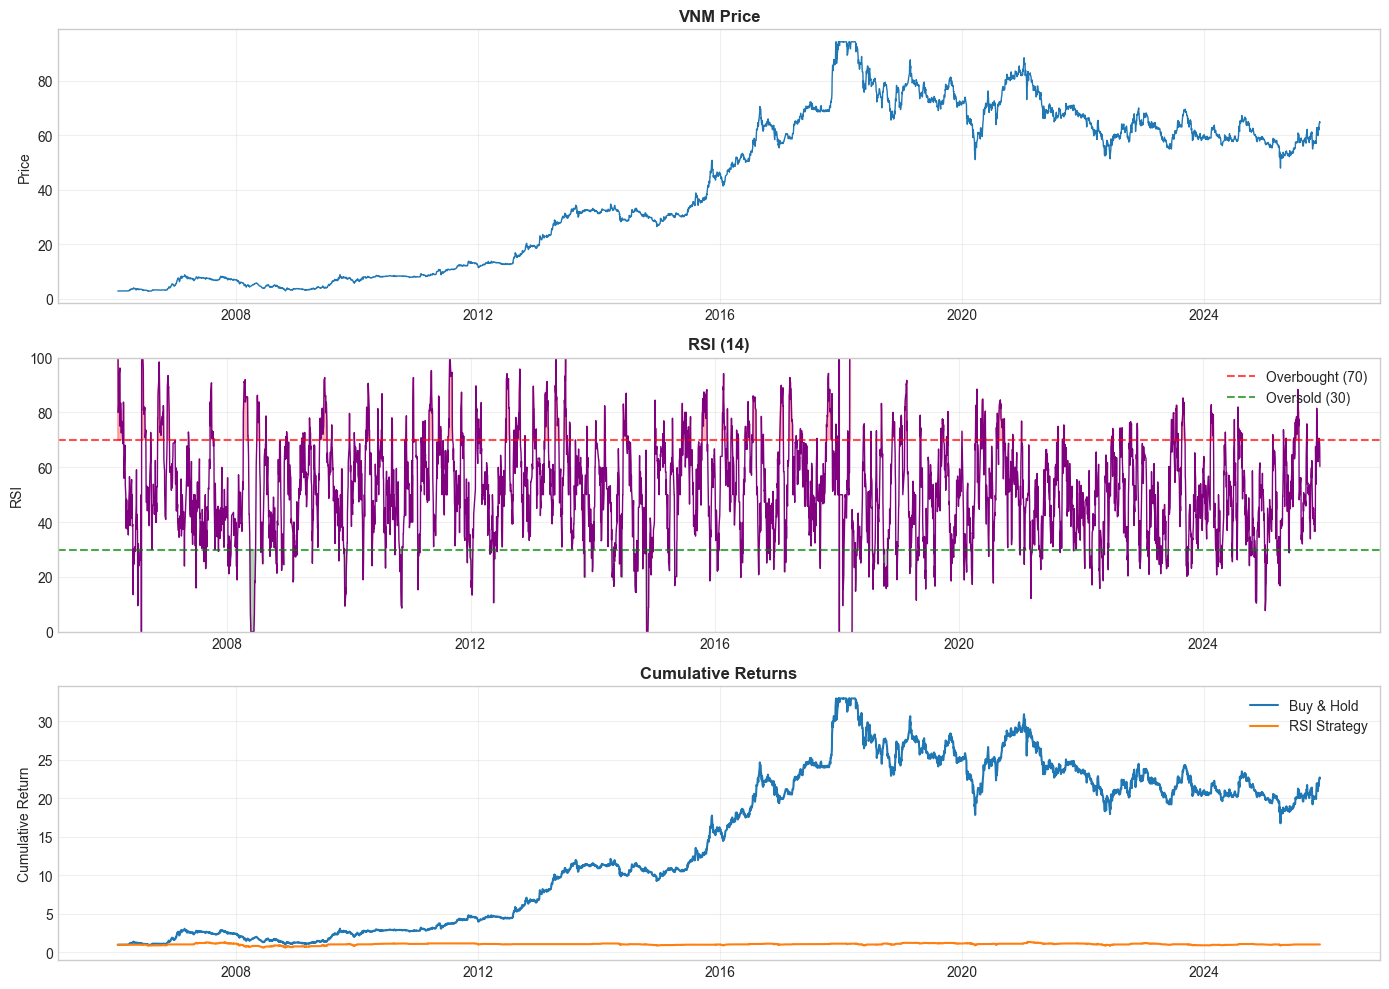

In [7]:
# ========== DEMO 2: RSI MOMENTUM ==========

strategy_2 = RSIMomentum(period=14, oversold=30, overbought=70)
result_2 = strategy_2.generate_signals(df)
backtest_2 = backtest_strategy(df, strategy_2)

# Print results
print_backtest_results(backtest_2, "RSI Momentum (14-period, 30/70)")

# Custom RSI visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Price
axes[0].plot(result_2['date'], result_2['adj_close'], linewidth=1)
axes[0].set_title(f'{SYMBOL} Price', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price')
axes[0].grid(True, alpha=0.3)

# RSI with zones
axes[1].plot(result_2['date'], result_2['rsi'], linewidth=1, color='purple')
axes[1].axhline(y=70, color='r', linestyle='--', alpha=0.7, label='Overbought (70)')
axes[1].axhline(y=30, color='g', linestyle='--', alpha=0.7, label='Oversold (30)')
axes[1].fill_between(result_2['date'], result_2['rsi'], 70, 
                     where=result_2['rsi'] >= 70, color='red', alpha=0.3)
axes[1].fill_between(result_2['date'], result_2['rsi'], 30, 
                     where=result_2['rsi'] <= 30, color='green', alpha=0.3)
axes[1].set_title('RSI (14)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RSI')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Cumulative Returns
data_2 = backtest_2['data']
axes[2].plot(data_2['date'], data_2['cumulative_market'], label='Buy & Hold')
axes[2].plot(data_2['date'], data_2['cumulative_strategy_net'], label='RSI Strategy')
axes[2].set_title('Cumulative Returns', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Cumulative Return')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


MACD Momentum (12, 26, 9)
Total Return:   600.26%
Annual Return:  10.41%
Sharpe Ratio:   0.54
Max Drawdown:   -52.06%
Win Rate:       44.17%
Num Trades:     183


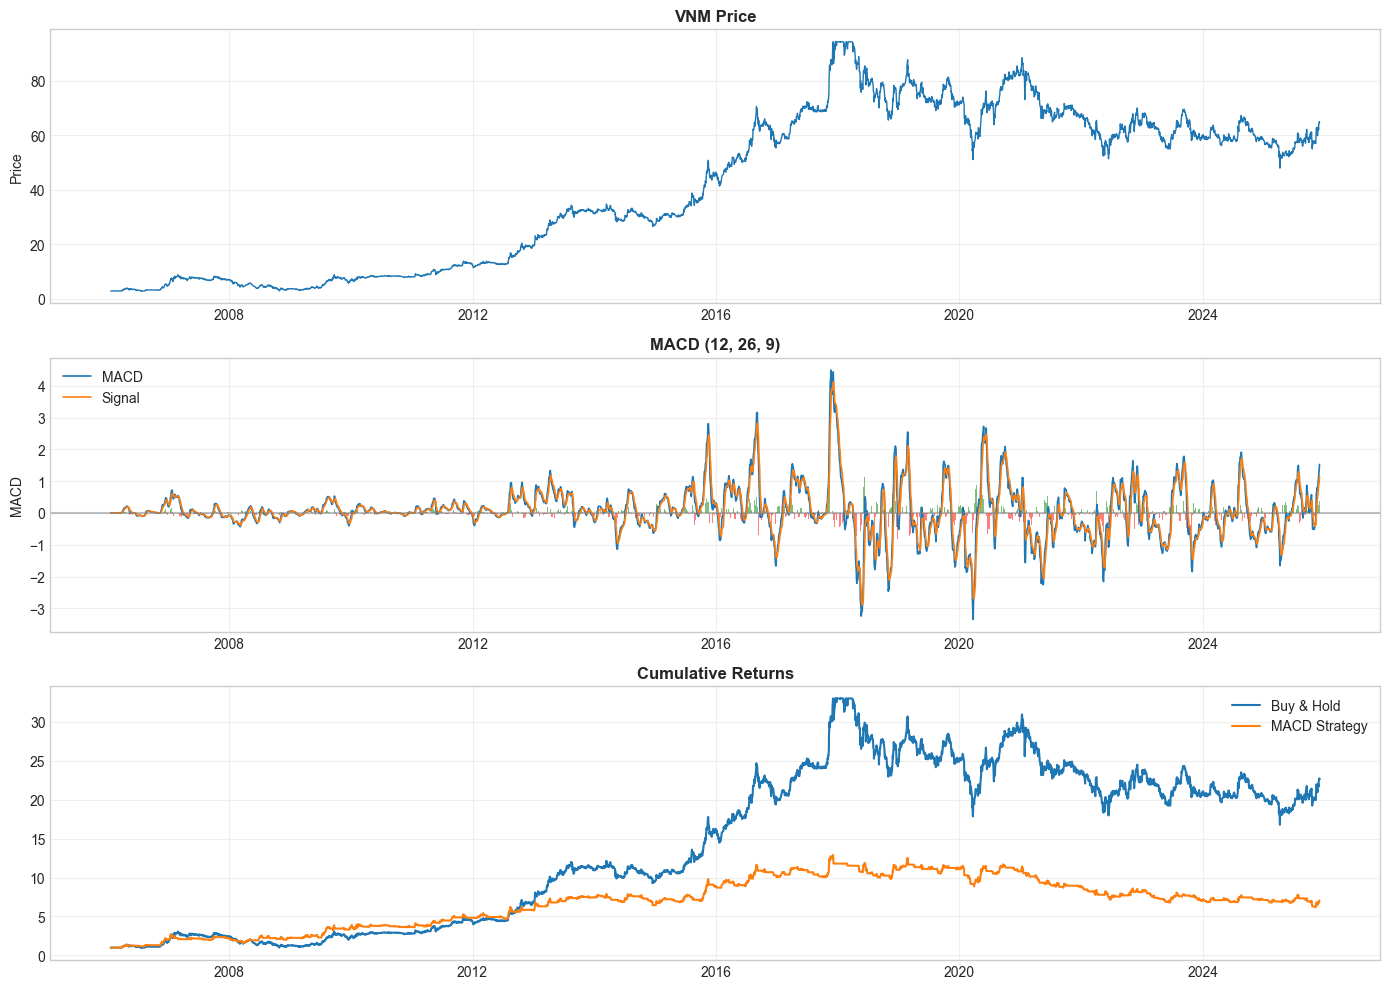

In [8]:
# ========== DEMO 3: MACD MOMENTUM ==========

strategy_3 = MACDMomentum(fast=12, slow=26, signal=9)
result_3 = strategy_3.generate_signals(df)
backtest_3 = backtest_strategy(df, strategy_3)

# Print results
print_backtest_results(backtest_3, "MACD Momentum (12, 26, 9)")

# Custom MACD visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Price
axes[0].plot(result_3['date'], result_3['adj_close'], linewidth=1)
axes[0].set_title(f'{SYMBOL} Price', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price')
axes[0].grid(True, alpha=0.3)

# MACD
axes[1].plot(result_3['date'], result_3['macd'], label='MACD', linewidth=1.2)
axes[1].plot(result_3['date'], result_3['macd_signal'], label='Signal', linewidth=1.2)
colors = ['green' if v >= 0 else 'red' for v in result_3['macd_hist']]
axes[1].bar(result_3['date'], result_3['macd_hist'], color=colors, alpha=0.5, width=1)
axes[1].axhline(y=0, color='gray', linestyle='-', alpha=0.5)
axes[1].set_title('MACD (12, 26, 9)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MACD')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

# Returns
data_3 = backtest_3['data']
axes[2].plot(data_3['date'], data_3['cumulative_market'], label='Buy & Hold')
axes[2].plot(data_3['date'], data_3['cumulative_strategy_net'], label='MACD Strategy')
axes[2].set_title('Cumulative Returns', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1.2 Fundamental Strategies Demo

Demo 3 fundamental strategies:
1. **Value Investing** - P/E, P/B, EV/EBITDA
2. **Quality Investing** - ROE, ROA, Margins
3. **Piotroski F-Score** - Financial strength scoring

VALUE INVESTING RANKINGS - Year 2024
Scoring: P/E (40%) + P/B (30%) + EV/EBITDA (30%) | Lower = Better
------------------------------------------------------------
1. VHM: Score=0.840 | P/E=5.2 | P/B=0.8 | EV/EBITDA=12.3
2. VPB: Score=0.565 | P/E=9.4 | P/B=1.0 | EV/EBITDA=nan
3. ACB: Score=0.545 | P/E=6.6 | P/B=1.3 | EV/EBITDA=nan
4. HPG: Score=0.510 | P/E=14.2 | P/B=1.5 | EV/EBITDA=10.8
5. VIC: Score=0.490 | P/E=13.1 | P/B=1.1 | EV/EBITDA=28.4
6. VNM: Score=0.470 | P/E=13.0 | P/B=3.8 | EV/EBITDA=10.4
7. BID: Score=0.405 | P/E=10.4 | P/B=1.8 | EV/EBITDA=nan
8. MWG: Score=0.250 | P/E=23.9 | P/B=3.2 | EV/EBITDA=14.9
9. VCB: Score=0.215 | P/E=15.0 | P/B=2.6 | EV/EBITDA=nan
10. MSN: Score=0.210 | P/E=50.6 | P/B=3.3 | EV/EBITDA=14.6


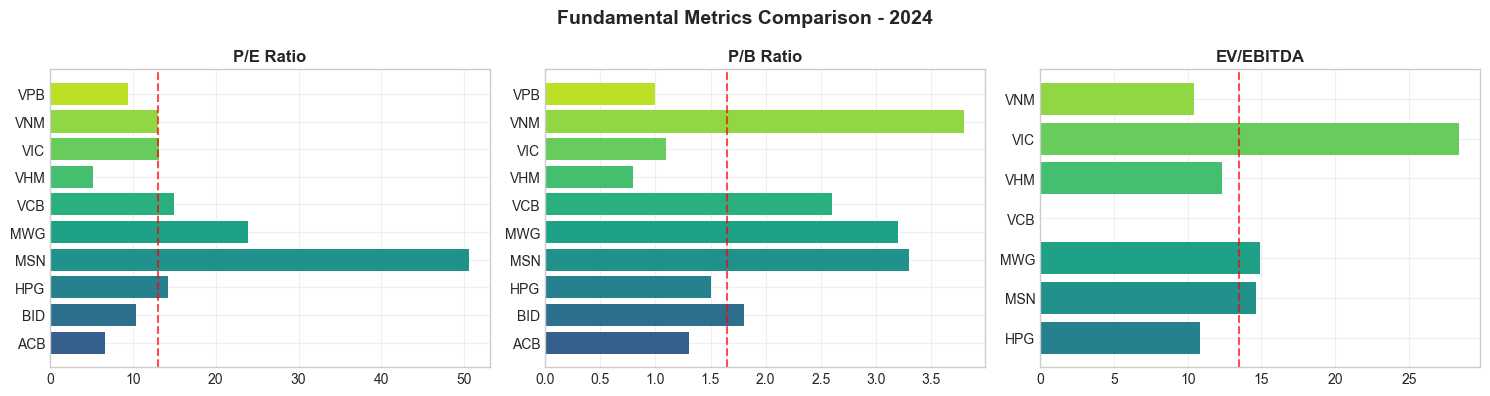

In [9]:
# ========== DEMO 1: VALUE INVESTING ==========

value_strategy = ValueStrategy(pe_weight=0.4, pb_weight=0.3, ev_ebitda_weight=0.3)
value_rankings = value_strategy.rank_stocks(fund_data, YEAR)

print(f"VALUE INVESTING RANKINGS - Year {YEAR}")
print("="*60)
print("Scoring: P/E (40%) + P/B (30%) + EV/EBITDA (30%) | Lower = Better")
print("-"*60)

for rank, (symbol, score) in enumerate(value_rankings, 1):
    merged = merge_fundamental_data(fund_data[symbol])
    year_data = merged[merged['year'] == YEAR]
    if not year_data.empty:
        row = year_data.iloc[-1]
        pe = row.get('priceToEarning', np.nan)
        pb = row.get('priceToBook', np.nan)
        ev = row.get('valueBeforeEbitda', np.nan)
        print(f"{rank}. {symbol}: Score={score:.3f} | P/E={pe:.1f} | P/B={pb:.1f} | EV/EBITDA={ev:.1f}")

# Visualize valuation metrics
plot_fundamental_comparison(
    fund_data, list(fund_data.keys()), YEAR,
    {'P/E Ratio': 'priceToEarning', 'P/B Ratio': 'priceToBook', 'EV/EBITDA': 'valueBeforeEbitda'}
)

QUALITY INVESTING RANKINGS - Year 2024
Scoring: ROE, ROA, Margins, Low Leverage | Higher = Better
------------------------------------------------------------
1. ACB: Score=0.848 | ROE=21.7% | ROA=2.1% | D/E=nan | GM=nan%
2. VCB: Score=0.767 | ROE=18.7% | ROA=1.7% | D/E=nan | GM=nan%
3. BID: Score=0.757 | ROE=19.5% | ROA=1.0% | D/E=nan | GM=nan%
4. VNM: Score=0.690 | ROE=29.4% | ROA=17.4% | D/E=0.30 | GM=41.4%
5. VPB: Score=0.597 | ROE=11.4% | ROA=1.8% | D/E=nan | GM=nan%
6. VHM: Score=0.470 | ROE=16.7% | ROA=6.3% | D/E=0.40 | GM=32.2%
7. VIC: Score=0.330 | ROE=9.5% | ROA=1.6% | D/E=1.50 | GM=14.4%
8. MWG: Score=0.290 | ROE=14.6% | ROA=5.7% | D/E=1.00 | GM=20.5%
9. HPG: Score=0.210 | ROE=11.1% | ROA=5.8% | D/E=0.70 | GM=13.3%
10. MSN: Score=0.140 | ROE=7.0% | ROA=1.4% | D/E=1.60 | GM=29.6%


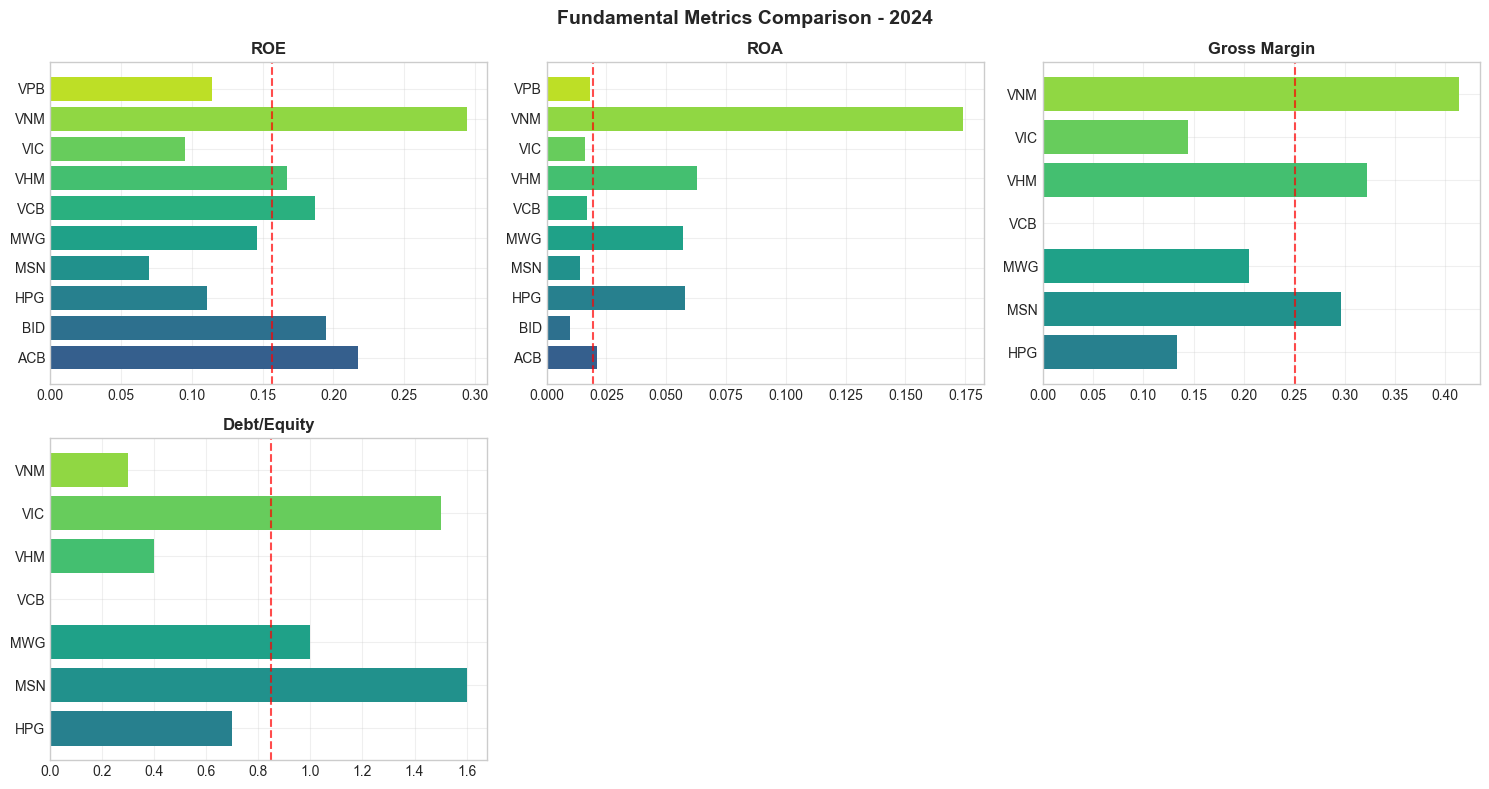

In [10]:
# ========== DEMO 2: QUALITY INVESTING ==========

quality_strategy = QualityStrategy()
quality_rankings = quality_strategy.rank_stocks(fund_data, YEAR)

print(f"QUALITY INVESTING RANKINGS - Year {YEAR}")
print("="*60)
print("Scoring: ROE, ROA, Margins, Low Leverage | Higher = Better")
print("-"*60)

for rank, (symbol, score) in enumerate(quality_rankings, 1):
    merged = merge_fundamental_data(fund_data[symbol])
    year_data = merged[merged['year'] == YEAR]
    if not year_data.empty:
        row = year_data.iloc[-1]
        roe = row.get('roe', np.nan)
        roa = row.get('roa', np.nan)
        de = row.get('debtOnEquity', np.nan)
        gm = row.get('grossProfitMargin', np.nan)
        print(f"{rank}. {symbol}: Score={score:.3f} | ROE={roe:.1%} | ROA={roa:.1%} | D/E={de:.2f} | GM={gm:.1%}")

# Visualize quality metrics
plot_fundamental_comparison(
    fund_data, list(fund_data.keys()), YEAR,
    {'ROE': 'roe', 'ROA': 'roa', 'Gross Margin': 'grossProfitMargin', 'Debt/Equity': 'debtOnEquity'}
)

PIOTROSKI F-SCORE ANALYSIS - Year 2024

F-Score Components (0-9 points):
PROFITABILITY (4 pts): Positive ROA, Positive OCF, ROA improvement, OCF > NI
LEVERAGE (3 pts):      Lower D/A, Higher Current Ratio, No dilution
EFFICIENCY (2 pts):    Higher Gross Margin, Higher Asset Turnover

----------------------------------------------------------------------
ACB: F-Score = 2/9 🔴 AVOID
BID: F-Score = 3/9 🔴 AVOID
HPG: F-Score = 4/9 🔴 AVOID
MSN: F-Score = 7/9 🟢 STRONG BUY
MWG: F-Score = 6/9 🟡 HOLD
VCB: F-Score = 4/9 🔴 AVOID
VHM: F-Score = 2/9 🔴 AVOID
VIC: F-Score = 5/9 🟡 HOLD
VNM: F-Score = 5/9 🟡 HOLD
VPB: F-Score = 5/9 🟡 HOLD

Best F-Score: MSN (7/9)


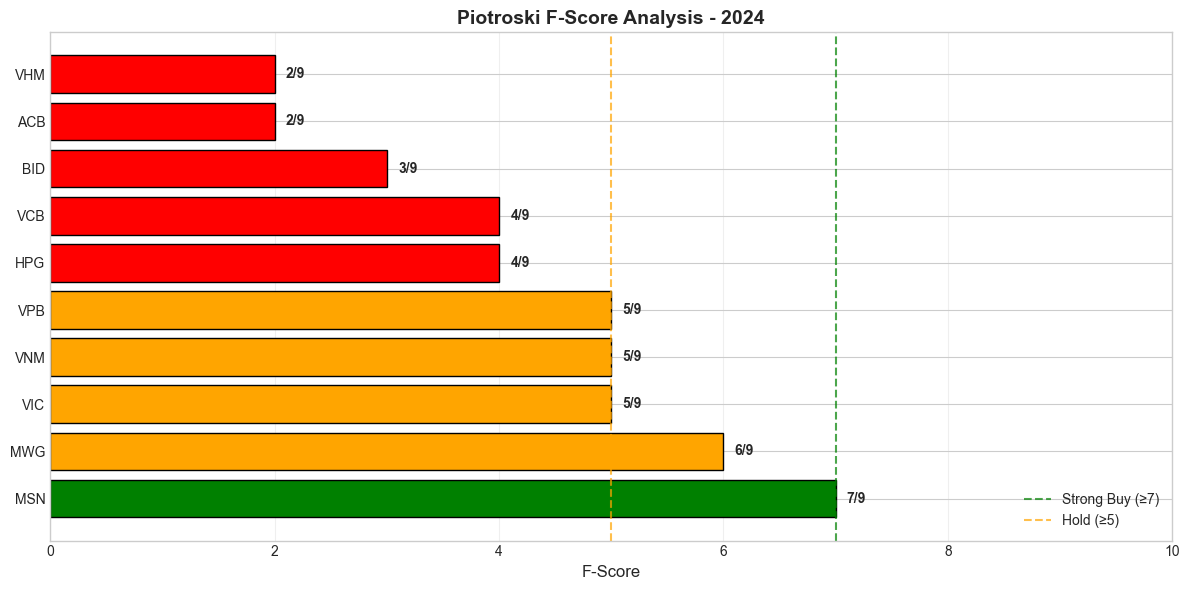

In [11]:
# ========== DEMO 3: PIOTROSKI F-SCORE ==========

print(f"PIOTROSKI F-SCORE ANALYSIS - Year {YEAR}")
print("="*70)
print("""
F-Score Components (0-9 points):
PROFITABILITY (4 pts): Positive ROA, Positive OCF, ROA improvement, OCF > NI
LEVERAGE (3 pts):      Lower D/A, Higher Current Ratio, No dilution
EFFICIENCY (2 pts):    Higher Gross Margin, Higher Asset Turnover
""")
print("-"*70)

f_scores = []
for symbol, data in fund_data.items():
    merged = merge_fundamental_data(data)
    score = calculate_piotroski_score(merged, YEAR)
    f_scores.append((symbol, score))
    status = "🟢 STRONG BUY" if score >= 7 else "🟡 HOLD" if score >= 5 else "🔴 AVOID"
    print(f"{symbol}: F-Score = {score}/9 {status}")

# Sort by F-Score
f_scores.sort(key=lambda x: x[1], reverse=True)
print(f"\nBest F-Score: {f_scores[0][0]} ({f_scores[0][1]}/9)")

# Visualize F-Scores
fig, ax = plt.subplots(figsize=(12, 6))
symbols = [s for s, _ in f_scores]
scores = [sc for _, sc in f_scores]
colors = ['green' if sc >= 7 else 'orange' if sc >= 5 else 'red' for sc in scores]

bars = ax.barh(symbols, scores, color=colors, edgecolor='black', linewidth=1)
for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
            f'{score}/9', va='center', fontweight='bold')

ax.axvline(x=7, color='green', linestyle='--', alpha=0.7, label='Strong Buy (≥7)')
ax.axvline(x=5, color='orange', linestyle='--', alpha=0.7, label='Hold (≥5)')
ax.set_xlim(0, 10)
ax.set_xlabel('F-Score', fontsize=12)
ax.set_title(f'Piotroski F-Score Analysis - {YEAR}', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---
# Part II: Compare All Strategies


MOMENTUM STRATEGIES COMPARISON - VNM


,Strategy,Total Return,Annual Return,Volatility,Sharpe Ratio,Max Drawdown,Win Rate,Num Trades
0,Price Momentum,1925.64%,16.54%,21.13%,0.78,-61.24%,50.07%,52
1,ROC Momentum,1766.35%,16.05%,19.97%,0.80,-58.24%,42.52%,327
2,RSI Momentum,4.06%,0.20%,18.63%,0.01,-52.71%,46.15%,55
3,MACD Momentum,600.26%,10.41%,19.44%,0.54,-52.06%,44.17%,183
4,Volume-Weighted Momentum,210.41%,5.93%,10.66%,0.56,-21.81%,27.95%,309
5,OBV Momentum,1277.09%,14.27%,20.39%,0.70,-45.33%,45.00%,252
6,VPT Momentum,1373.91%,14.67%,20.49%,0.72,-49.07%,45.58%,196
7,MFI Momentum,73.33%,2.84%,17.16%,0.17,-55.22%,47.02%,23
8,Triple Momentum,198.80%,5.73%,15.10%,0.38,-34.25%,44.22%,137
9,Accelerating Momentum,72.71%,2.82%,16.10%,0.18,-58.24%,35.25%,390


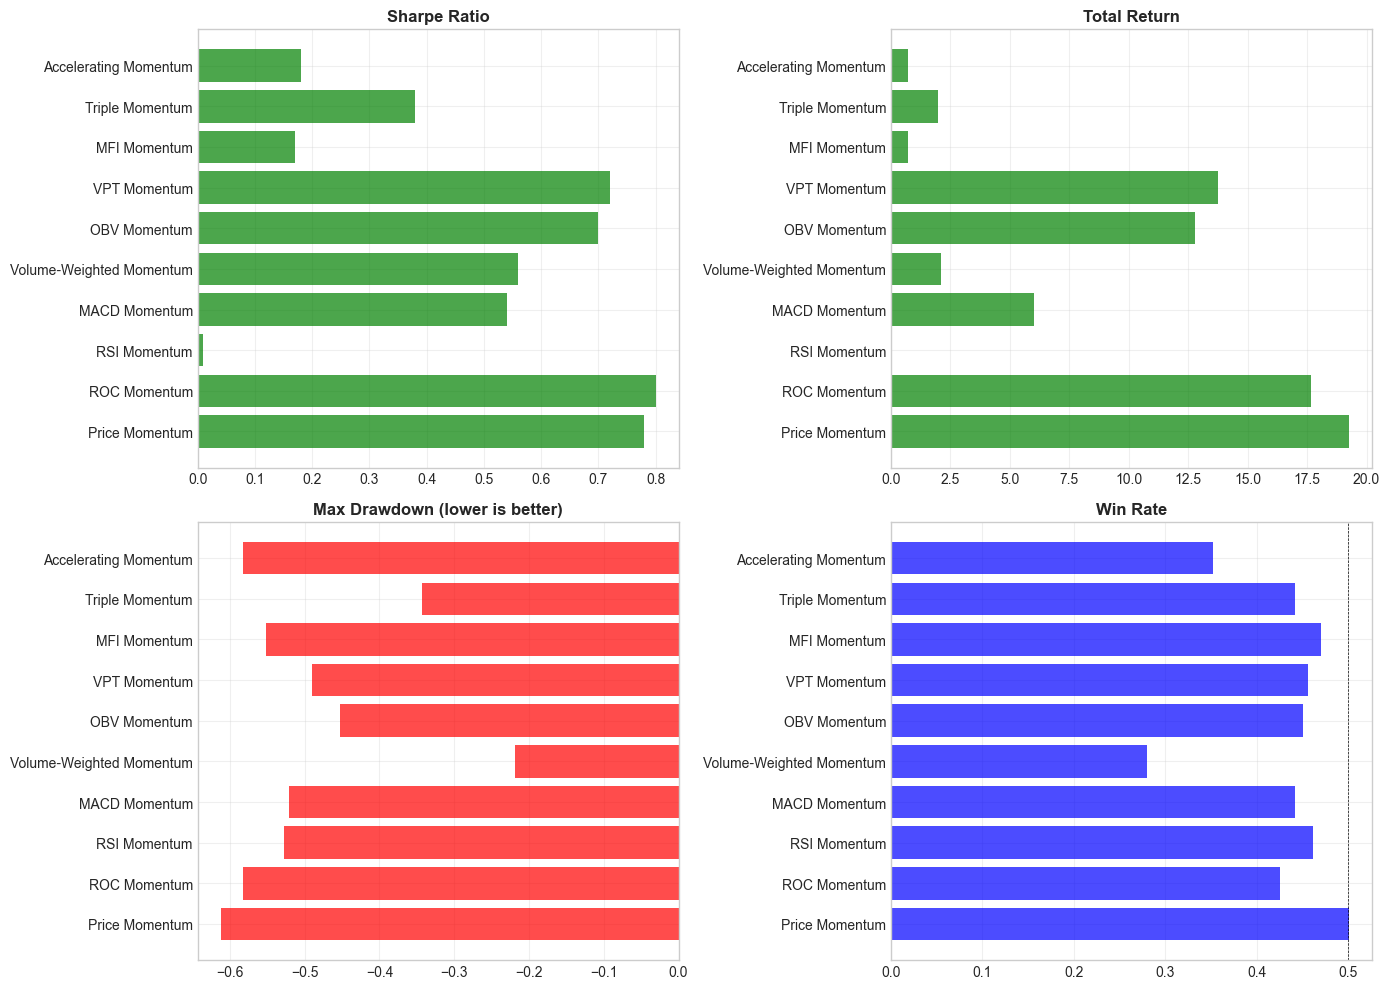

In [12]:
# ========== COMPARE ALL MOMENTUM STRATEGIES ==========

momentum_strategies = [
    PriceMomentum(short_window=20, long_window=50),
    ROCMomentum(period=12),
    RSIMomentum(period=14),
    MACDMomentum(),
    VolumeWeightedMomentum(),
    OBVMomentum(),
    VPTMomentum(),
    MFIMomentum(),
    TripleMomentum(),
    AcceleratingMomentum()
]

# Compare all strategies
momentum_comparison = compare_strategies(df, momentum_strategies)

print(f"\n{'='*100}")
print(f"MOMENTUM STRATEGIES COMPARISON - {SYMBOL}")
print("="*100)
display(momentum_comparison)

# Visualize comparison
plot_comparison_charts(momentum_comparison)


FUNDAMENTAL STRATEGIES COMPARISON - Year 2024


,Strategy,#1 Pick,#2 Pick,#3 Pick
0,Value Investing,VHM,VPB,ACB
1,Quality Investing,ACB,VCB,BID
2,Growth Investing,VIC,MWG,VPB
3,GARP,MWG,VIC,VHM
4,Piotroski F-Score,MSN,MWG,VIC
5,Dividend Strategy,VHM,MSN,HPG
6,Free Cash Flow,VHM,VNM,MWG
7,Composite Multi-Factor,VPB,ACB,VIC
8,Balance Sheet Strength,VPB,ACB,VCB



CONSENSUS TOP PICKS (frequency in Top 3):
----------------------------------------
  VHM: 4/9 strategies
  VPB: 4/9 strategies
  ACB: 4/9 strategies
  VIC: 4/9 strategies
  MWG: 4/9 strategies
  VCB: 2/9 strategies
  MSN: 2/9 strategies
  BID: 1/9 strategies
  HPG: 1/9 strategies
  VNM: 1/9 strategies


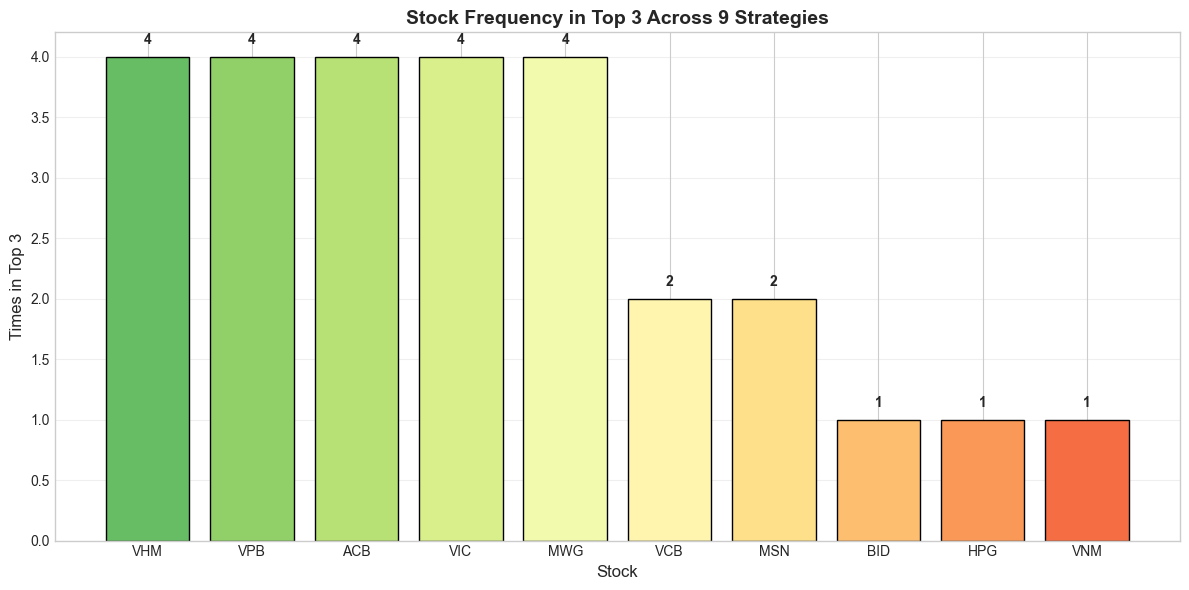

In [13]:
# ========== COMPARE ALL FUNDAMENTAL STRATEGIES ==========

fundamental_strategies = [
    ("Value Investing", ValueStrategy()),
    ("Quality Investing", QualityStrategy()),
    ("Growth Investing", GrowthStrategy()),
    ("GARP", GARPStrategy()),
    ("Piotroski F-Score", PiotroskiStrategy()),
    ("Dividend Strategy", DividendStrategy()),
    ("Free Cash Flow", FCFStrategy()),
    ("Composite Multi-Factor", CompositeStrategy()),
    ("Balance Sheet Strength", BalanceSheetStrength())
]

print(f"\n{'='*100}")
print(f"FUNDAMENTAL STRATEGIES COMPARISON - Year {YEAR}")
print("="*100)

fund_results = []
for name, strategy in fundamental_strategies:
    rankings = strategy.rank_stocks(fund_data, YEAR)
    top_3 = [s for s, _ in rankings[:3]]
    fund_results.append({
        'Strategy': name,
        '#1 Pick': top_3[0] if len(top_3) > 0 else '-',
        '#2 Pick': top_3[1] if len(top_3) > 1 else '-',
        '#3 Pick': top_3[2] if len(top_3) > 2 else '-'
    })

fund_comparison_df = pd.DataFrame(fund_results)
display(fund_comparison_df)

# Count consensus picks
from collections import Counter
all_picks = []
for name, strategy in fundamental_strategies:
    rankings = strategy.rank_stocks(fund_data, YEAR)
    all_picks.extend([s for s, _ in rankings[:3]])

pick_counts = Counter(all_picks)
sorted_picks = sorted(pick_counts.items(), key=lambda x: x[1], reverse=True)

print(f"\nCONSENSUS TOP PICKS (frequency in Top 3):")
print("-"*40)
for symbol, count in sorted_picks:
    print(f"  {symbol}: {count}/{len(fundamental_strategies)} strategies")

# Visualize consensus
fig, ax = plt.subplots(figsize=(12, 6))
symbols = [x[0] for x in sorted_picks]
counts = [x[1] for x in sorted_picks]
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(symbols)))[::-1]

bars = ax.bar(symbols, counts, color=colors, edgecolor='black', linewidth=1)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
            str(count), ha='center', fontweight='bold')

ax.set_ylabel('Times in Top 3', fontsize=12)
ax.set_xlabel('Stock', fontsize=12)
ax.set_title(f'Stock Frequency in Top 3 Across {len(fundamental_strategies)} Strategies', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
# Part III: Cross-sectional Momentum

In [14]:
# ========== CROSS-SECTIONAL MOMENTUM PORTFOLIO ==========

# Create momentum portfolio
portfolio = MomentumPortfolio(lookback=252, holding_period=21, top_n=3)

# Get latest common date
latest_dates = [data['date'].max() for data in all_data.values()]
latest_date = min(latest_dates)

print(f"CROSS-SECTIONAL MOMENTUM PORTFOLIO")
print("="*60)
print(f"Construction Date: {latest_date}")
print(f"Lookback: 252 days (12 months)")
print(f"Holding Period: 21 days")
print(f"Top N: 3 stocks")
print("-"*60)

# Calculate momentum scores
scores = portfolio.calculate_momentum_scores(all_data, latest_date)

print("\n12-Month Momentum Scores (Return):")
print("-"*40)
for symbol, score in sorted(scores.items(), key=lambda x: x[1], reverse=True):
    status = "⬆️" if score > 0 else "⬇️"
    print(f"  {symbol}: {score:>8.2%} {status}")

# Get portfolio weights
weights = portfolio.get_portfolio_weights(all_data, latest_date)

print(f"\nRecommended Portfolio (Top 3 Momentum):")
print("-"*40)
for symbol, weight in weights.items():
    print(f"  {symbol}: {weight:.1%}")

CROSS-SECTIONAL MOMENTUM PORTFOLIO
Construction Date: 2025-12-03 00:00:00
Lookback: 252 days (12 months)
Holding Period: 21 days
Top N: 3 stocks
------------------------------------------------------------

12-Month Momentum Scores (Return):
----------------------------------------
  VIC:  321.22% ⬆️
  VHM:  151.80% ⬆️
  VPB:   63.07% ⬆️
  MWG:   48.77% ⬆️
  HPG:   21.82% ⬆️
  ACB:   16.37% ⬆️
  MSN:   11.33% ⬆️
  VNM:    9.25% ⬆️
  BID:    1.91% ⬆️
  VCB:   -4.32% ⬇️

Recommended Portfolio (Top 3 Momentum):
----------------------------------------
  VIC: 33.3%
  VHM: 33.3%
  VPB: 33.3%


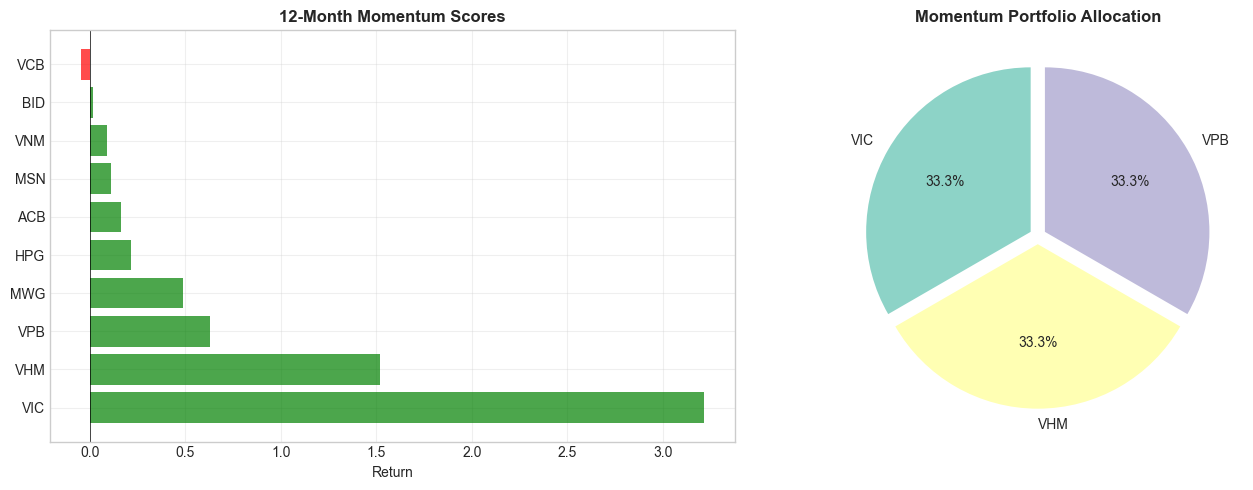

In [15]:
# Visualize momentum scores and portfolio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Momentum scores bar chart
sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
symbols = [s for s, _ in sorted_scores]
momentum_vals = [sc for _, sc in sorted_scores]
colors = ['green' if v > 0 else 'red' for v in momentum_vals]

axes[0].barh(symbols, momentum_vals, color=colors, alpha=0.7)
axes[0].set_title('12-Month Momentum Scores', fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='black', linewidth=0.5)
axes[0].set_xlabel('Return')
axes[0].grid(True, alpha=0.3)

# Portfolio allocation pie chart
portfolio_symbols = list(weights.keys())
portfolio_weights = list(weights.values())
axes[1].pie(portfolio_weights, labels=portfolio_symbols, autopct='%1.1f%%', 
           startangle=90, colors=plt.cm.Set3.colors[:len(portfolio_symbols)],
           explode=[0.05]*len(portfolio_symbols))
axes[1].set_title('Momentum Portfolio Allocation', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
# ========== FUNDAMENTAL-BASED PORTFOLIO ==========

# Build portfolio using Composite Multi-Factor Strategy
composite_strategy = CompositeStrategy()
fund_portfolio = FundamentalPortfolio(strategy=composite_strategy, top_n=3)

# Construct portfolio
fund_weights = fund_portfolio.construct_portfolio(fund_data, YEAR)
portfolio_metrics = fund_portfolio.get_portfolio_metrics(fund_data, YEAR)

print(f"COMPOSITE MULTI-FACTOR PORTFOLIO - Year {YEAR}")
print("="*70)
print("Strategy: Value (25%) + Quality (25%) + Growth (25%) + Momentum (25%)")
print("-"*70)
print("\nPortfolio Allocation:")
for symbol, weight in fund_weights.items():
    print(f"  {symbol}: {weight:.1%}")

print("\nPortfolio Holdings Details:")
display(portfolio_metrics)

COMPOSITE MULTI-FACTOR PORTFOLIO - Year 2024
Strategy: Value (25%) + Quality (25%) + Growth (25%) + Momentum (25%)
----------------------------------------------------------------------

Portfolio Allocation:
  VPB: 33.3%
  ACB: 33.3%
  VIC: 33.3%

Portfolio Holdings Details:


,Symbol,Weight,P/E,P/B,ROE,ROA,Debt/Equity,Dividend
0,VPB,33.3%,9.4,1.0,11.4%,1.8%,NaN,2.7%
1,ACB,33.3%,6.6,1.3,21.7%,2.1%,NaN,4.6%
2,VIC,33.3%,13.1,1.1,9.5%,1.6%,1.5,N/A


---
# Part IV: Multi-stock Comparison

In [17]:
# ========== MULTI-STOCK MOMENTUM STRATEGY COMPARISON ==========

# Run best momentum strategy on all stocks
best_momentum = PriceMomentum(short_window=20, long_window=50)

results_all = []
for symbol, data in all_data.items():
    try:
        result = backtest_strategy(data, best_momentum)
        results_all.append({
            'Symbol': symbol,
            'Total Return': f"{result['total_return']:.2%}",
            'Annual Return': f"{result['annual_return']:.2%}",
            'Sharpe Ratio': f"{result['sharpe_ratio']:.2f}",
            'Max Drawdown': f"{result['max_drawdown']:.2%}",
            'Win Rate': f"{result['win_rate']:.2%}",
            'Num Trades': int(result['num_trades'])
        })
    except Exception as e:
        print(f"Error with {symbol}: {e}")

results_df = pd.DataFrame(results_all)
print("\nPRICE MOMENTUM STRATEGY (SMA 20/50) - ALL STOCKS")
print("="*80)
display(results_df)


PRICE MOMENTUM STRATEGY (SMA 20/50) - ALL STOCKS


,Symbol,Total Return,Annual Return,Sharpe Ratio,Max Drawdown,Win Rate,Num Trades
0,ACB,471.01%,9.71%,0.42,-40.81%,49.28%,54
1,BID,303.71%,12.64%,0.51,-44.19%,49.01%,30
2,HPG,5981.84%,25.87%,1.02,-40.36%,51.61%,38
3,MSN,244.44%,8.08%,0.32,-60.94%,47.93%,45
4,MWG,221.77%,10.91%,0.41,-65.84%,52.56%,32
5,VCB,338.10%,9.50%,0.44,-36.67%,50.07%,45
6,VHM,42.16%,4.81%,0.20,-47.50%,48.08%,25
7,VIC,2769.98%,20.48%,0.82,-54.87%,49.75%,43
8,VNM,1925.64%,16.54%,0.78,-61.24%,50.07%,52
9,VPB,111.65%,9.56%,0.38,-53.48%,50.35%,24


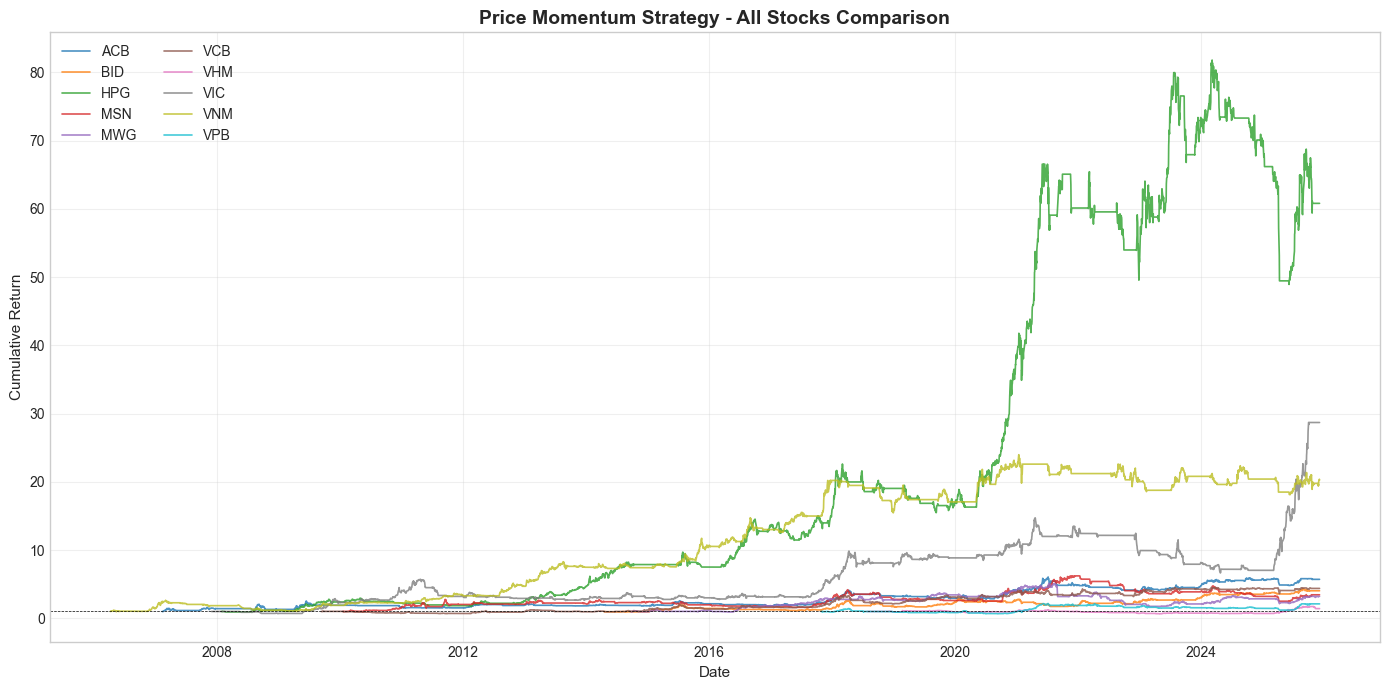

In [18]:
# ========== CUMULATIVE RETURNS COMPARISON ACROSS STOCKS ==========

fig, ax = plt.subplots(figsize=(14, 7))

for symbol, data in all_data.items():
    try:
        result = backtest_strategy(data, best_momentum)
        result_data = result['data'].dropna()
        ax.plot(result_data['date'], result_data['cumulative_strategy_net'], 
               label=symbol, linewidth=1.2, alpha=0.8)
    except:
        pass

ax.set_title('Price Momentum Strategy - All Stocks Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Cumulative Return', fontsize=11)
ax.legend(loc='upper left', ncol=2)
ax.grid(True, alpha=0.3)
ax.axhline(y=1, color='black', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [19]:
# ========== FUNDAMENTAL METRICS COMPARISON ACROSS STOCKS ==========

print(f"\nFUNDAMENTAL METRICS COMPARISON - Year {YEAR}")
print("="*80)

# Collect all metrics
fund_metrics_all = []
for symbol, data in fund_data.items():
    merged = merge_fundamental_data(data)
    year_data = merged[merged['year'] == YEAR]
    if not year_data.empty:
        row = year_data.iloc[-1]
        f_score = calculate_piotroski_score(merged, YEAR)
        fund_metrics_all.append({
            'Symbol': symbol,
            'P/E': f"{row.get('priceToEarning', np.nan):.1f}",
            'P/B': f"{row.get('priceToBook', np.nan):.1f}",
            'ROE': f"{row.get('roe', np.nan):.1%}",
            'ROA': f"{row.get('roa', np.nan):.1%}",
            'D/E': f"{row.get('debtOnEquity', np.nan):.2f}",
            'F-Score': f"{f_score}/9",
            'Dividend': f"{row.get('dividend', 0):.1%}" if not pd.isna(row.get('dividend')) else 'N/A'
        })

fund_metrics_df = pd.DataFrame(fund_metrics_all)
display(fund_metrics_df)


FUNDAMENTAL METRICS COMPARISON - Year 2024


,Symbol,P/E,P/B,ROE,ROA,D/E,F-Score,Dividend
0,ACB,6.6,1.3,21.7%,2.1%,nan,2/9,4.6%
1,BID,10.4,1.8,19.5%,1.0%,nan,3/9,1.2%
2,HPG,14.2,1.5,11.1%,5.8%,0.70,4/9,N/A
3,MSN,50.6,3.3,7.0%,1.4%,1.60,7/9,N/A
4,MWG,23.9,3.2,14.6%,5.7%,1.00,6/9,1.7%
5,VCB,15.0,2.6,18.7%,1.7%,nan,4/9,0.7%
6,VHM,5.2,0.8,16.7%,6.3%,0.40,2/9,N/A
7,VIC,13.1,1.1,9.5%,1.6%,1.50,5/9,N/A
8,VNM,13.0,3.8,29.4%,17.4%,0.30,5/9,7.4%
9,VPB,9.4,1.0,11.4%,1.8%,nan,5/9,2.7%


In [20]:
# ========== GENERATE DETAILED REPORT FOR TOP PICK ==========

# Get the most recommended stock
top_pick = sorted_picks[0][0]
print(f"Generating detailed report for top consensus pick: {top_pick}")
print(generate_stock_report(top_pick, fund_data, YEAR))

Generating detailed report for top consensus pick: VHM

FUNDAMENTAL ANALYSIS REPORT: VHM
Year: 2024

VALUATION METRICS
-----------------
P/E Ratio:        5.2
P/B Ratio:        0.8
EV/EBITDA:        12.3
Dividend Yield:   nan

PROFITABILITY
-------------
ROE:              0.167
ROA:              0.063
Gross Margin:     0.322
Operating Margin: 0.24
Net Margin:       0.311

GROWTH
------
Revenue Growth:   -0.012
Earnings Growth:  -0.047
EPS Change:       -0.047

FINANCIAL HEALTH
----------------
Current Ratio:    1.0
Quick Ratio:      0.8
Debt/Equity:      0.4
Interest Coverage:3.2

EFFICIENCY
----------
Asset Turnover:   0.2
Days Receivable:  68.0
Days Inventory:   289.0

QUALITY SCORE
-------------
Piotroski F-Score: 2/9 (Weak)




In [21]:
# ========== SUMMARY ==========

print("\n" + "="*70)
print("TRADING STRATEGIES ANALYSIS - SUMMARY")
print("="*70)

print("""
KEY FINDINGS:

1. MOMENTUM STRATEGIES:
   - Price Momentum (MA Crossover): Simple trend-following, effective in trending markets
   - RSI: Mean-reversion signals, useful in range-bound markets
   - MACD: Combines trend and momentum confirmation

2. FUNDAMENTAL STRATEGIES:
   - Value: Identifies undervalued stocks (low P/E, P/B)
   - Quality: Focuses on high ROE, margins, low leverage
   - Piotroski F-Score: Comprehensive financial health scoring

3. PORTFOLIO CONSTRUCTION:
   - Cross-sectional momentum ranks stocks by 12-month returns
   - Composite multi-factor combines Value + Quality + Growth + Momentum

RECOMMENDATIONS:
   - Use momentum strategies for market timing
   - Use fundamental strategies for stock selection
   - Combine both for a robust investment approach
   - Monitor F-Score for financial health changes
""")

# Best momentum strategy
best_sharpe_idx = momentum_comparison['Sharpe Ratio'].apply(float).idxmax()
print(f"Best Momentum Strategy (by Sharpe): {momentum_comparison.iloc[best_sharpe_idx]['Strategy']}")

# Best fundamental pick
print(f"Best Fundamental Pick (consensus): {sorted_picks[0][0]} ({sorted_picks[0][1]} strategies)")

# Top momentum portfolio
print(f"\nMomentum Portfolio: {', '.join(weights.keys())}")
print(f"Fundamental Portfolio: {', '.join(fund_weights.keys())}")


TRADING STRATEGIES ANALYSIS - SUMMARY

KEY FINDINGS:

1. MOMENTUM STRATEGIES:
   - Price Momentum (MA Crossover): Simple trend-following, effective in trending markets
   - RSI: Mean-reversion signals, useful in range-bound markets
   - MACD: Combines trend and momentum confirmation

2. FUNDAMENTAL STRATEGIES:
   - Value: Identifies undervalued stocks (low P/E, P/B)
   - Quality: Focuses on high ROE, margins, low leverage
   - Piotroski F-Score: Comprehensive financial health scoring

3. PORTFOLIO CONSTRUCTION:
   - Cross-sectional momentum ranks stocks by 12-month returns
   - Composite multi-factor combines Value + Quality + Growth + Momentum

RECOMMENDATIONS:
   - Use momentum strategies for market timing
   - Use fundamental strategies for stock selection
   - Combine both for a robust investment approach
   - Monitor F-Score for financial health changes

Best Momentum Strategy (by Sharpe): ROC Momentum
Best Fundamental Pick (consensus): VHM (4 strategies)

Momentum Portfolio: VIC